In [2]:
import analysing_utils
import matplotlib.pyplot as plt

## Figure

In [ ]:
results = analysing_utils.load_mcts_results()

problems = ["h2", "h2o", "lih", "vqls_0", "vqls_1"]
optimal_value = {"h2": 1.117, "h2o": 75.4217, "lih": 7.973, "vqls_0": 0, "vqls_1": 0}

variants = [ 'selection-UCB', 'selection-UCB_tuned-1.41', 'selection-UCB_tuned-0.4', 'selection-RAVE', 'selection-RAVE_0.5', 'selection-1_grams', 'selection-2_grams', 'selection-3_grams']

convergence = analysing_utils.converge_all(results, problems, variants)

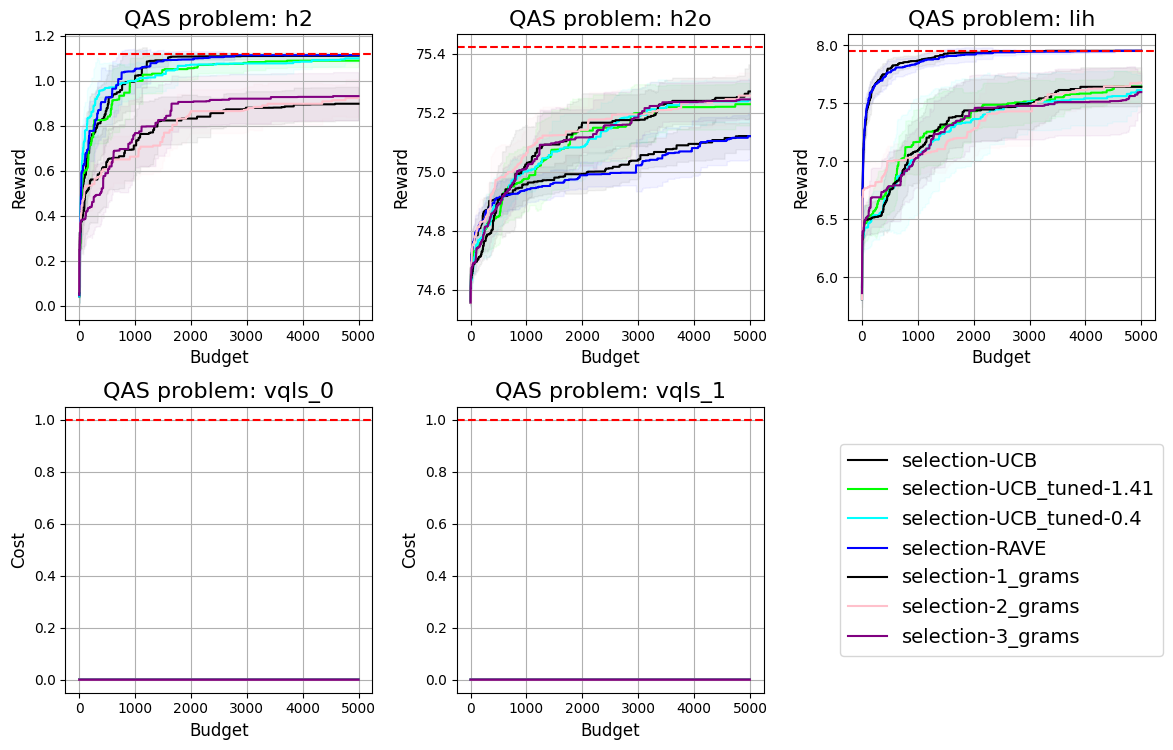

In [ ]:
color_palette =  {
    "selection-UCB": 'green',
    'selection-UCB_tuned-1.41': 'lime',
    'selection-UCB_tuned-0.4': 'cyan',
    "selection-RAVE": 'blue',
    'selection-RAVE_0.5': 'beige',
    'selection-1_grams': 'black',
    'selection-2_grams': 'pink',
    'selection-3_grams': "purple",
}

baseline = None

analysing_utils.plot_figure(problems, variants, optimal_value, convergence, color_palette, baseline)

## Boxplot

In [14]:
import analysing_utils
import matplotlib.pyplot as plt
import pandas as pd

finished
[[1.1173490283616343, 1.1173490341636998, 1.1173490036030582, 1.1173490017792973, 1.1173490315348034, 1.1173490030517688, 1.1173490342649233, 1.11734902983555, 1.1173490331542502, 1.1173490242886597], [1.1173488030808627, 1.1173487718777635, 1.1173489451165954, 1.1173470357799913, 1.117349029234516, 1.1173490200199074, 1.1173489213381689, 1.1173489998859965, 1.1173490341898134, 1.117349004455552], [1.1173490341122496, 1.117348438735691, 1.1173489504816467, 1.1173489280476263, 1.117349030007019, 1.1173490235231582, 1.1173489206478475, 1.136188123754837, 1.117348995550554, 1.1173490280036118], [1.1173489256812237, 1.1173489576673143, 1.1173490130701502, 1.1173489623285096, 1.1173490133751105, 1.1173490313903485, 1.1173490337271867, 1.1173490212945538, 1.1173490119177392, 1.1173479881760289], [1.1173485907119216, 1.117349010530465, 1.1173490105703818, 1.1173490231741063, 1.1173490229784515, 1.1173490010339988, 1.1173490024425796, 1.1173490064169898, 1.1173489532667271, 1.11734901

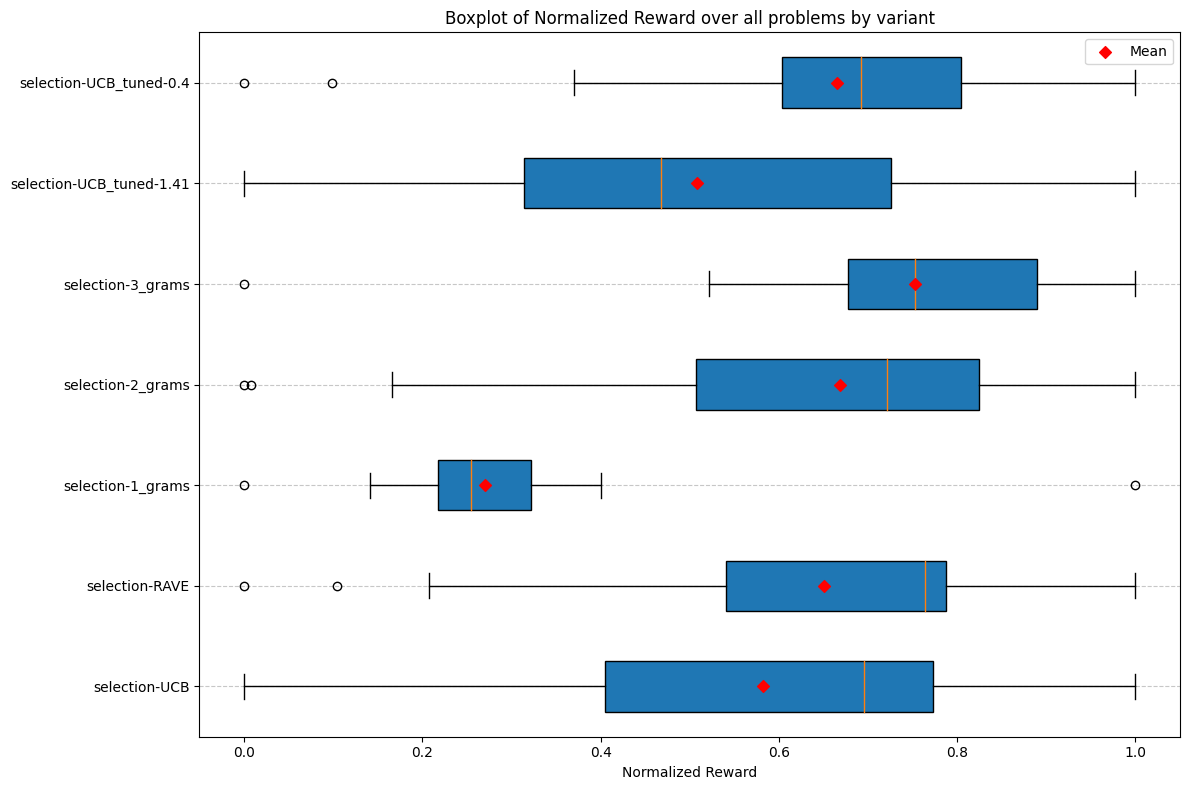

NameError: name 'mlines' is not defined

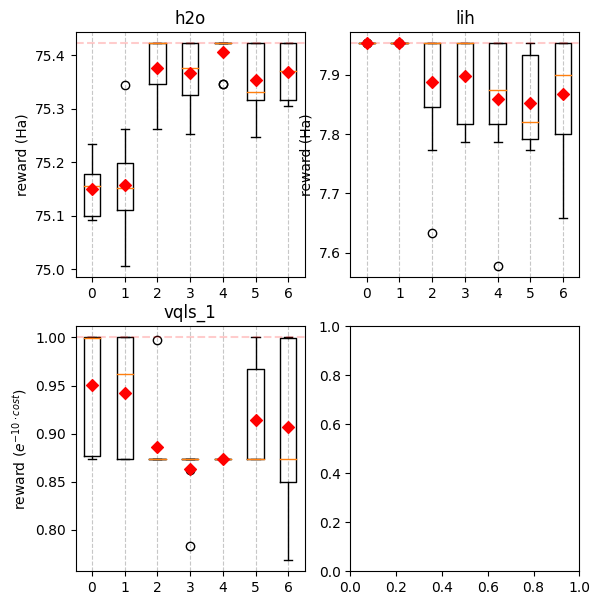

In [ ]:
problems = ['h2', 'h2o', 'lih', 'vqls_0', 'vqls_1']
vql_problems = ['vqls_0', 'vqls_1']
chemistry_problems = ['h2', 'h2o', 'lih']
optimal_value = {'h2': 1.117, 'h2o': 75.42175236224648, 'lih': 7.95265005, 'vqls_0': 1, 'vqls_1': 1}

split_variants = []
for variant in variants:
    split_variants = split_variants + variant.split('_')
unique_vars = list(set(split_variants))
unique_vars

table_df = pd.DataFrame(columns=unique_vars)
table_df.head()

for variant in variants:
    variant.split('_')
    for col in unique_vars:
        table_df.at[variant, col] = 1 if col in variant.split('_') else 0

results = analysing_utils.load_mcts_results()
circuit_results = analysing_utils.load_circuit_results()

problem_stats = {}
for problem in problems:
    problem_results = []
    for variant in variants:
        problem_results.append(circuit_results[problem][variant])
    print('finished')
    print(problem_results)
    problem_stats[problem] =  analysing_utils.standardize_problem_stats(problem_results)
    print(problem_stats[problem])
print(circuit_results)
problem_stats
# IDK what this does
# analysing_utils.standardize_from_stats(problem_stats["h2"], circuit_results["h2"]["gates"][0])


import numpy as np

# variant_results = {}
# for variant in variants:
#     standardized_results = []
#     for problem in problems:
#         for run in circuit_results[problem][variant]:
#             result = analysing_utils.standardize_from_stats(problem_stats[problem], run)
#             standardized_results.append(result)
#     variant_results[variant] = standardized_results
    
# plt.figure(figsize=(12, 8))

# # Create the boxplot
# bp = plt.boxplot(variant_results.values(), labels=variant_results.keys(), vert=False, patch_artist=True)

# # Calculate the means
# means = [np.mean(values) for values in variant_results.values()]
# positions = np.arange(1, len(means) + 1)  # Y positions for horizontal boxplot

# # Plot the means as red diamonds
# plt.scatter(means, positions, color='red', marker='D', label='Mean', zorder=3)

# # Add labels and title
# plt.xlabel('Standardized Reward')
# plt.title('Boxplot of Standardized Reward over all problems by variant')
# plt.grid(axis='y', linestyle='--', alpha=0.7)  # Horizontal grid lines
# plt.legend()
# plt.tight_layout()
# plt.show()



# Assuming `variants`, `problems`, `circuit_results`, and `problem_stats` are defined earlier in the code
variant_results = {}

# Standardize and normalize the results
for variant in variants:
    standardized_results = []
    for problem in problems:
        for run in circuit_results[problem][variant]:
            # Standardize the result using your custom standardization function
            result = analysing_utils.standardize_from_stats(problem_stats[problem], run)
            standardized_results.append(result)
    
    # Normalize the standardized results to the [0, 1] range
    min_val = np.min(standardized_results)
    max_val = np.max(standardized_results)
    normalized_results = (standardized_results - min_val) / (max_val - min_val)
    
    # Store the normalized results
    variant_results[variant] = normalized_results

# Create the boxplot for normalized results
plt.figure(figsize=(12, 8))

# Create the boxplot
bp = plt.boxplot(variant_results.values(), labels=variant_results.keys(), vert=False, patch_artist=True)

# Calculate the means of the normalized results
means = [np.mean(values) for values in variant_results.values()]
positions = np.arange(1, len(means) + 1)  # Y positions for horizontal boxplot

# Plot the means as red diamonds
plt.scatter(means, positions, color='red', marker='D', label='Mean', zorder=3)

# Add labels and title
plt.xlabel('Normalized Reward')
plt.title('Boxplot of Normalized Reward over all problems by variant')
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Horizontal grid lines
plt.legend()
plt.tight_layout()
plt.show()

curate = variants
circuit_results_curated = {
    problem: {key: circuit_results[problem][key] for key in curate if key in circuit_results[problem]}
    for problem in problems
}

problems_curated = problems.copy()
# Removing 'vqls_0' and 'h2'
problems_curated.remove('vqls_0')
problems_curated.remove('h2')

# Create subplots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(6.5, 7))
axes = axes.flatten()

# Plotting loop
for i, problem in enumerate(problems_curated):
    ax = axes[i]
    data = list(circuit_results_curated[problem].values())

    # Create boxplot
    bp = ax.boxplot(data, labels=range(len(data)))

    # Calculate means and plot them as red diamonds
    means = [np.mean(values) for values in data]
    positions = np.arange(1, len(means) + 1)  # Match box positions
    ax.scatter(positions, means, color='red', marker='D', label='Mean' if i == 0 else "", zorder=3)

    # Plot the optimal value line
    ax.axhline(y=optimal_value[problem], color='red', linestyle='--', alpha=0.2)

    ax.set_title(f"{problem}")
    if problem in ['h2o', 'lih']:
        ax.set_ylabel("reward (Ha)")
    else:
        ax.set_ylabel(r"reward ($e^{-10 \cdot cost}$)")

    ax.grid(axis='x', linestyle='--', alpha=0.7)  # Add horizontal grid lines

# Set up the labels for the legend
labels = variants

# Create dummy handles for the boxplot labels
handles = [mlines.Line2D([], [], color='black', marker=f'${i}$', linestyle='None') for i in range(8)]

# Add Mean handle at the front
mean_handle = mlines.Line2D([], [], color='red', marker='D', linestyle='None', label='Mean')

# Create combined legend
fig.legend(
    [mean_handle] + handles,
    ['Mean'] + labels,
    loc='lower right',
    ncol=1,
    bbox_to_anchor=(1, 0.1),
    prop={'size': 8}
)

# Hide the last subplot for layout balance
axes[-1].axis('off')

plt.tight_layout()
plt.show()